# Intro

In this tutorial, we show the robustness of ARGEN to confounders. This tutorial generates Fig. 4c.

# Setting directory and loading required packages

In [1]:
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman", repos = "https://cloud.r-project.org")

pacman::p_load(here,dplyr, data.table,ggplot2)

DIR <- here::here()   # resolves to the repo root automatically
ncores=5

# Reading in chromosome specific ARGEN fit (standard fitting without GEM group) from Tutorial 3.

In [2]:
meta_data_allchr <- fread(paste0(DIR,'/data/auxiliary/meta_data_allchr.csv'))
id2name <- meta_data_allchr %>%
distinct(gene_id, gene) %>%
mutate(across(everything(), as.character))



chrlist=paste0('chr',c(1:22,"X"))
true_edges=c()
all_edges=c()
for(chr in c(1:23)){
chrlist=paste0('chr',c(1:22,"X"))
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
setwd(DAG_DIR)
dag_artifact=readRDS(file = 'dag_0.05BH_0.05onlineBH.rds')
true_edges=rbind(true_edges,data.frame(chr=chrlist[chr],dag_artifact$dag_edges))
all_edges=rbind(all_edges,data.frame(chr=chrlist[chr],do.call('rbind',dag_artifact$dag_object$edge_structure_all)))
    }


true_edges_name=  true_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    rename(to_gene = gene)


all_edges_name=all_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    rename(to_gene = gene)



true_edges_name=true_edges_name %>% dplyr::select(from_gene,to_gene,coef,p_raw)%>% mutate(edge=paste0(from_gene,"_",to_gene))

# Running ARGEN including GEM group

In [ ]:
source(paste0(DIR,'/code/function/Proxy_IV_functions_parallel.R'))

chrlist=paste0('chr',c(1:22,"X"))

for(chr in 1:23){
  print(chr)    
  
  # -------------------------------
  # Paths / output
  # -------------------------------
  DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
  
  if (!dir.exists(DAG_DIR)) dir.create(DAG_DIR, recursive = TRUE, showWarnings = FALSE)
  
  # -------------------------------
  # Load data (your paths)
  X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
  meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))
  
  # Design matrix D (exactly as you had)
  perturbation_unique <- unique(meta_data$gene_id)
  meta_data$gene_id <- factor(meta_data$gene_id,
                                            levels = unique(meta_data$gene_id))
  meta_data$gem_group<-factor(meta_data$gem_group)
  
  D <- model.matrix(~ gene_id - 1, data = meta_data)
  colnames(D) <- sub("^gene_id", "", colnames(D))
  D <- D[, -c(length(perturbation_unique))]  # keep your exclusion
  control_ind <- which(rowSums(D) == 0)
  
  # Offset vector (depth)
  C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)
  
  
  # Basic checks
  nodes <- colnames(X_raw)
  p <- length(nodes)
  options(future.globals.maxSize = 10 * 1024^3) 
  ds_out <- build_descendants_cov_adjust(
    X_raw = X_raw,
    D = D, 
    control_ind = control_ind,
    alpha_desc = 0.05, nodes = nodes,
    padj_method = "BH",
    cc_cols=c('mitopercent','gem_group'),
    cc_df=meta_data %>% as.data.frame,depth=C,
    ncores = ncores, engine = "multisession", blas_threads = 1
  )
  
  alpha_IV <- 0.05
  
  
  dag_obj <- dag_search_perturbseq(
    desc_sets = ds_out$descendant_set_score_closure,
    data_raw  = X_raw ,
    D = D ,depth =C,family = 'poisson',cc_df=data.frame(meta_data),
    cc_cols = c('mitopercent','gem_group'),alpha_parent=alpha_IV,
    padj_method_parent='onlineBH',
    cores = ncores, blas_threads = 1
  )
  
  # Save DAG artifact (cache)
  edges_k <- edges_from_dagsearch(dag_obj)
  maps_k  <- compute_ancestors_map(nodes, edges_k)
  dag_artifact <- list(
    dag_object    = dag_obj,
    dag_edges     = edges_k,
    parents_map   = maps_k$parents_map,
    ancestors_map = maps_k$ancestors_map
  )
  
  
  saveRDS(dag_artifact, file = file.path(DAG_DIR,  'dag_0.05BH_0.05onlineBH_include_GEM.rds'))
  print(paste0(chr," complete!"))        
}

# Reading in chromosome specific ARGEN fit including GEM group as a covariate.

In [3]:
chrlist=paste0('chr',c(1:22,"X"))
true_edges=c()
all_edges=c()

for(chr in c(1:23)){
chrlist=paste0('chr',c(1:22,"X"))
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
setwd(DAG_DIR)
setwd(DAG_DIR)
dag_artifact=readRDS(file = 'dag_0.05BH_0.05onlineBH_include_GEM.rds')
true_edges=rbind(true_edges,data.frame(chr=chrlist[chr],dag_artifact$dag_edges))
all_edges=rbind(all_edges,data.frame(chr=chrlist[chr],do.call('rbind',dag_artifact$dag_object$edge_structure_all)))
}


true_edges_name_with_gem=  true_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    rename(to_gene = gene)


all_edges_name_with_gem=all_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    rename(to_gene = gene)
true_edges_name_with_gem=true_edges_name_with_gem %>% dplyr::select(from_gene,to_gene,coef,p_raw) %>% mutate(edge=paste0(from_gene,"_",to_gene))

# Fig.4c

Warning message:
“Removed 7 rows containing missing values or values outside the scale range (`geom_point()`).”


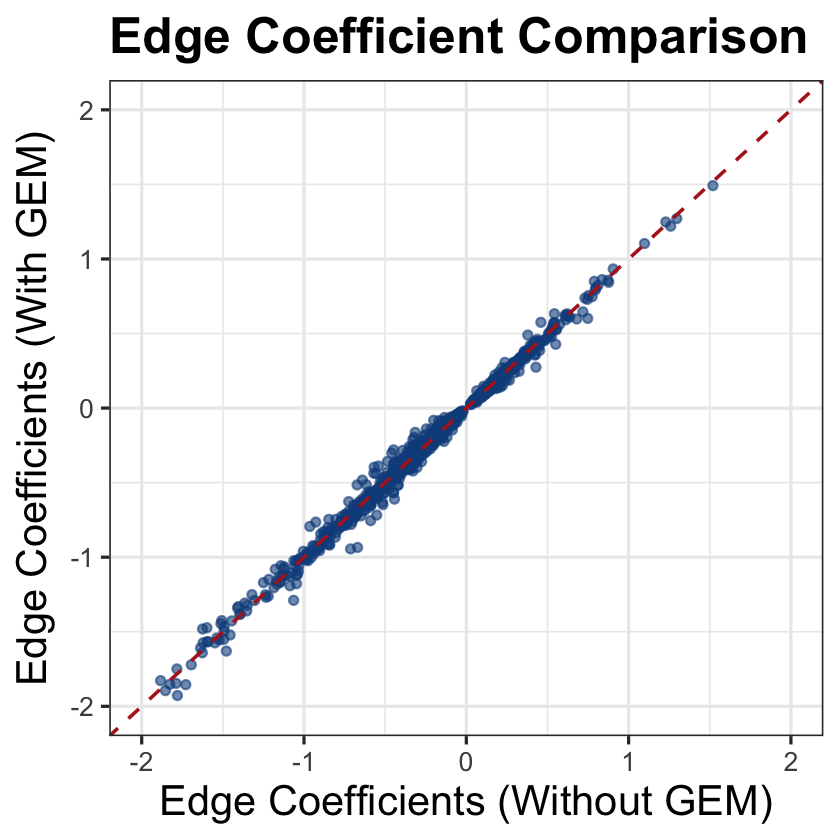

In [4]:


tmp=merge(true_edges_name,true_edges_name_with_gem,by='edge')

ggplot(tmp, aes(x = coef.x, y = coef.y)) +
  # Use transparency (alpha) to show overlapping points
  geom_point(alpha = 0.6, color = "dodgerblue4", size = 2) +
  # Add the y=x reference line
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "firebrick", linewidth = 1) +
  # Add descriptive labels
  labs(
    title = "Edge Coefficient Comparison",
    x = "Edge Coefficients (Without GEM)",
    y = "Edge Coefficients (With GEM)"
  ) +
  # Apply a clean theme
  theme_bw(base_size = 20) +
  theme(
    plot.title = element_text(face = "bold", size = 30),
    plot.subtitle = element_text(color = "grey40", size = 15),
    axis.title = element_text(size=25)
  ) +xlim(-2,2) +ylim(-2,2)